In [8]:
# ============================================================
#  PHASE 4 — EMOTIONAL FRAMING ANALYSIS
#  Sentiment + clickbait features of headlines vs click-through
# ============================================================

# ---------- installs (run once) ----------
!pip -q install vaderSentiment textblob

# ---------- imports ----------
import pandas as pd, numpy as np, re
import matplotlib.pyplot as plt, seaborn as sns
import statsmodels.formula.api as smf
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from textblob import TextBlob

sns.set_theme(style="whitegrid"); plt.rcParams["figure.figsize"]=(10,5)

PATH = "/content/mind_merged_train.csv"   # adjust if needed
df = pd.read_csv(PATH, usecols=["news_id","clicked","category","title"])
df["title"] = df["title"].fillna("")
print(f"Loaded {len(df):,} rows | {df['news_id'].nunique():,} unique articles")

Loaded 5,843,444 rows | 20,288 unique articles


In [9]:
# ===== STEP 1: ARTICLE-LEVEL TABLE (one row per headline) =====
art = (df.groupby("news_id")
         .agg(impressions=("clicked","size"), clicks=("clicked","sum"),
              category=("category","first"), title=("title","first")))

# reliability filter: an article needs enough impressions for a stable CTR
MIN_IMPR = 20
art = art[art["impressions"] >= MIN_IMPR].copy()
art["ctr"] = art["clicks"] / art["impressions"]
print(f"{len(art):,} articles with >= {MIN_IMPR} impressions "
      f"(impression-weighted mean CTR = "
      f"{np.average(art['ctr'], weights=art['impressions']):.4f})")

6,180 articles with >= 20 impressions (impression-weighted mean CTR = 0.0404)


In [10]:
# ===== STEP 2: SENTIMENT SCORING =====
# VADER: rule-based, tuned for short text; compound in [-1, +1]
# TextBlob: polarity [-1,+1] and subjectivity [0,1]
analyzer = SentimentIntensityAnalyzer()
art["vader_compound"] = art["title"].apply(lambda s: analyzer.polarity_scores(s)["compound"])
art["tb_polarity"]    = art["title"].apply(lambda s: TextBlob(s).sentiment.polarity)
art["tb_subjectivity"]= art["title"].apply(lambda s: TextBlob(s).sentiment.subjectivity)

# coarse sentiment label for readable summaries
art["sentiment"] = pd.cut(art["vader_compound"], [-1.01,-0.05,0.05,1.01],
                          labels=["negative","neutral","positive"])
print(art[["vader_compound","tb_polarity","tb_subjectivity"]].describe().round(3))

       vader_compound  tb_polarity  tb_subjectivity
count        6180.000     6180.000         6180.000
mean            0.001        0.071            0.270
std             0.395        0.284            0.311
min            -0.948       -1.000            0.000
25%            -0.258        0.000            0.000
50%             0.000        0.000            0.133
75%             0.250        0.136            0.500
max             0.929        1.000            1.000


In [11]:
# ===== STEP 3: CLICKBAIT FEATURE EXTRACTION =====
CLICKBAIT_WORDS = set("""shocking amazing unbelievable incredible stunning secret
reveals revealed surprising mistake warning never always best worst ultimate epic
insane genius hilarious heartbreaking jaw-dropping mind-blowing breaking exclusive
proves slams destroys""".split())

def extract(s):
    words = s.split(); low = s.lower()
    return pd.Series({
        "has_number":   int(bool(re.search(r"\d", s))),                       # listicles / stats
        "has_question": int("?" in s or bool(re.match(r"(?i)^(how|why|what|who|when|which|where)\b", s))),
        "has_exclaim":  int("!" in s),
        "has_you":      int(bool(re.search(r"(?i)\b(you|your)\b", s))),       # direct address
        "n_words":      len(words),
        "n_caps_words": sum(1 for w in words if len(w) > 1 and w.isupper()),  # SHOUTING
        "n_cb_words":   sum(1 for w in re.findall(r"[a-z]+", low) if w in CLICKBAIT_WORDS),
    })

art = pd.concat([art, art["title"].apply(extract)], axis=1)
print("Clickbait feature prevalence (share of articles):")
print(art[["has_number","has_question","has_exclaim","has_you"]].mean().round(3))

Clickbait feature prevalence (share of articles):
has_number      0.310
has_question    0.078
has_exclaim     0.009
has_you         0.080
dtype: float64


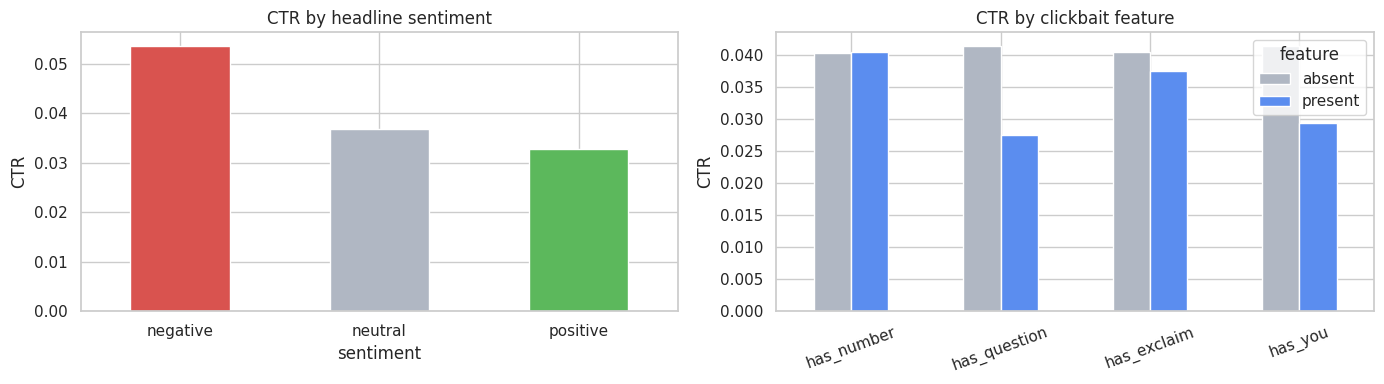

In [12]:
# ===== STEP 4: VISUALISE SENTIMENT & CLICKBAIT vs CTR =====
fig, ax = plt.subplots(1, 2, figsize=(14, 4))

# CTR by sentiment (impression-weighted)
s = (art.groupby("sentiment", observed=True)
        .apply(lambda d: np.average(d["ctr"], weights=d["impressions"]),
               include_groups=False))
s.plot(kind="bar", ax=ax[0], color=["#d9534f","#b0b7c3","#5cb85c"])
ax[0].set_title("CTR by headline sentiment"); ax[0].set_ylabel("CTR")
ax[0].tick_params(axis="x", rotation=0)

# CTR by presence of each clickbait feature
feat_ctr = {}
for f in ["has_number","has_question","has_exclaim","has_you"]:
    g = art.groupby(f).apply(lambda d: np.average(d["ctr"], weights=d["impressions"]),
                             include_groups=False)
    feat_ctr[f] = {"absent": g.get(0, np.nan), "present": g.get(1, np.nan)}
pd.DataFrame(feat_ctr).T.plot(kind="bar", ax=ax[1], color=["#b0b7c3","#5b8def"])
ax[1].set_title("CTR by clickbait feature"); ax[1].set_ylabel("CTR")
ax[1].tick_params(axis="x", rotation=20); ax[1].legend(title="feature")
plt.tight_layout(); plt.show()

In [13]:
# ===== STEP 5: REGRESSION (controls for category) =====
# Article-level weighted least squares: does framing predict CTR
# once topic is held constant? Weight by impressions (reliability).
model = smf.wls(
    "ctr ~ vader_compound + tb_subjectivity + n_words "
    "+ has_number + has_question + has_exclaim + has_you + n_cb_words "
    "+ C(category)",
    data=art, weights=art["impressions"]
).fit()

# show only the framing coefficients (hide the many category dummies)
keep = ["Intercept","vader_compound","tb_subjectivity","n_words",
        "has_number","has_question","has_exclaim","has_you","n_cb_words"]
res = pd.DataFrame({"coef": model.params, "p_value": model.pvalues}).loc[keep]
print(f"R-squared: {model.rsquared:.3f}\n")
print(res.round(4))
print("\n(Negative coef = lowers CTR; positive = raises CTR. "
      "p < 0.05 is conventionally 'significant'.)")

R-squared: 0.122

                   coef  p_value
Intercept        0.0182   0.0000
vader_compound  -0.0224   0.0000
tb_subjectivity -0.0093   0.0000
n_words          0.0013   0.0000
has_number       0.0021   0.0441
has_question    -0.0108   0.0000
has_exclaim      0.0018   0.6364
has_you         -0.0070   0.0001
n_cb_words       0.0068   0.0000

(Negative coef = lowers CTR; positive = raises CTR. p < 0.05 is conventionally 'significant'.)


In [14]:
# ===== STEP 6: BUILD A CLICKBAIT SCORE INDEX =====
# Composite 0-1 index from the clickbait signals (equal-weighted, standardised)
cb_feats = ["has_number","has_question","has_exclaim","has_you","n_caps_words","n_cb_words"]
z = (art[cb_feats] - art[cb_feats].mean()) / art[cb_feats].std(ddof=0)
art["clickbait_index"] = (z.mean(axis=1)
                          .pipe(lambda x: (x - x.min())/(x.max()-x.min())))  # scale to 0-1

# validate by COUNT OF SIGNALS present (robust to ties; more interpretable than quartiles)
art["cb_signals"] = (art[["has_number","has_question","has_exclaim","has_you"]].sum(axis=1)
                     + (art["n_caps_words"] > 0).astype(int)
                     + (art["n_cb_words"]  > 0).astype(int))
art["cb_group"] = art["cb_signals"].clip(upper=2).map(
    {0: "0 signals", 1: "1 signal", 2: "2+ signals"})

cb_ctr = (art.groupby("cb_group", observed=True)
             .apply(lambda d: pd.Series({
                 "articles": len(d),
                 "ctr": np.average(d["ctr"], weights=d["impressions"])}),
                 include_groups=False))
print(cb_ctr.round(4))

# example headlines at each extreme of the continuous index
print("\nMost 'clickbait' headlines:")
for tt in art.nlargest(5, "clickbait_index")["title"]: print("  +", tt)
print("\nLeast 'clickbait' headlines:")
for tt in art.nsmallest(5, "clickbait_index")["title"]: print("  -", tt)

art.to_csv("/content/phase4_headline_framing.csv")
print("\nSaved phase4_headline_framing.csv")

            articles     ctr
cb_group                    
0 signals     2719.0  0.0426
1 signal      2463.0  0.0421
2+ signals     998.0  0.0314

Most 'clickbait' headlines:
  + Happy Friday! What if You Always Had It Off? Why Don't You?
  + Can't-Miss Play: Jump-pass Pat! Mahomes' epic throw turns into 63-yard TD
  + The Best Backstage Moments From the 2019 E! People's Choice Awards
  + Ricky Gervais Hosting the 2020 Golden Globes: His Best Burns!
  + People's Choice Awards 2019: The Best Moments of the Night!

Least 'clickbait' headlines:
  - Man accused of threatening to 'gut' Rand Paul with an ax ordered to take meds
  - Russell Wilson, Richard Sherman swap jerseys despite supposed rift
  - Jets fans fly 'Fire Adam Gase' plane over New York City
  - Twitter is trying to figure out how to handle deepfakes
  - Boeing surges most since June on optimism over Max comeback

Saved phase4_headline_framing.csv
